# Analysis of PAC comodulogram metrics 


In [78]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr 
from matplotlib.lines import Line2D 

In [79]:
# ─── Load data ────────────────────────────────────────────────────────────────
basepath = Path('/Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis')
LFP_CSV_PATH = basepath / 'concatenated_lfp_stats.csv'
OUTPUT_DIR = LFP_CSV_PATH.parent.parent / 'LFP_analysis'
os.makedirs(OUTPUT_DIR, exist_ok=True)

GENO_ORDER  = ["WT", "NLGF"]
GENO_COLORS = {"NLGF": "#E07B54", "WT": "#5B8DB8"}

df = pd.read_csv(LFP_CSV_PATH)

# Clean names / categorical order
df["Genotype"] = pd.Categorical(df["Genotype"], categories=GENO_ORDER, ordered=True)
df["environment"] = df["environment"].astype(str)
df["mouse_name"] = df["mouse_name"].astype(str)
df["Experimenter"] = df["Experimenter"].astype(str)


## Run normality test for each metric

In [80]:
# ─── Metrics to analyse ───────────────────────────────────────────────────────
metrics = {
    "max_theta_freq": "Theta peak frequency (Hz)",
    "comodulogram_PAC_slow_gamma": "Theta–slow gamma PAC",
    "comodulogram_PAC_fast_gamma": "Theta–fast gamma PAC",
    "n_oscillatory_epochs_slow_gamm": "Slow gamma event count",
    "n_oscillatory_epochs_fast_gamma": "Fast gamma event count",
    "theta_running_slope": "Theta–running slope",
    "theta_running_intercept": "Theta–running intercept",
    "theta_running_rvalue": "Theta–running r",
}

metrics = {k: v for k, v in metrics.items() if k in df.columns}

# Run Shapiro-Wilk test for normality
from scipy.stats import shapiro
normality_results = {}
for metric in metrics.keys():
    stat, p_value = shapiro(df[metric].dropna())
    normality_results[metric] = (stat, p_value)
    print(f"Shapiro-Wilk test for {metric}: statistic={stat:.4f}, p-value={p_value:.4f}")
    print(f"Normality test for {metric}: {'Normal' if p_value > 0.05 else 'Not normal'}")


Shapiro-Wilk test for max_theta_freq: statistic=0.9696, p-value=0.4514
Normality test for max_theta_freq: Normal
Shapiro-Wilk test for comodulogram_PAC_slow_gamma: statistic=0.9024, p-value=0.0053
Normality test for comodulogram_PAC_slow_gamma: Not normal
Shapiro-Wilk test for comodulogram_PAC_fast_gamma: statistic=0.8572, p-value=0.0004
Normality test for comodulogram_PAC_fast_gamma: Not normal
Shapiro-Wilk test for n_oscillatory_epochs_slow_gamm: statistic=0.9319, p-value=0.0354
Normality test for n_oscillatory_epochs_slow_gamm: Not normal
Shapiro-Wilk test for n_oscillatory_epochs_fast_gamma: statistic=0.9254, p-value=0.0230
Normality test for n_oscillatory_epochs_fast_gamma: Not normal
Shapiro-Wilk test for theta_running_slope: statistic=0.9556, p-value=0.1935
Normality test for theta_running_slope: Normal
Shapiro-Wilk test for theta_running_intercept: statistic=0.9870, p-value=0.9539
Normality test for theta_running_intercept: Normal
Shapiro-Wilk test for theta_running_rvalue: sta

## Mann-Whitney analysis 

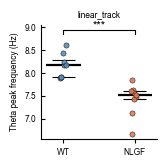

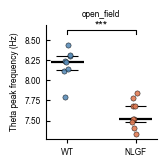

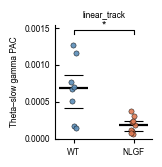

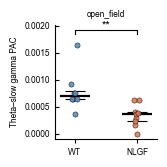

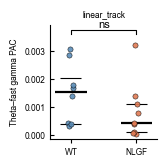

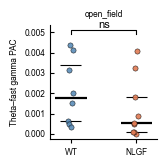

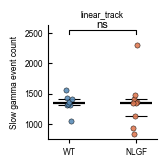

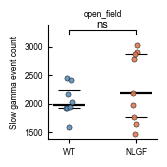

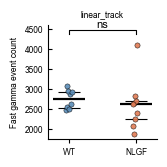

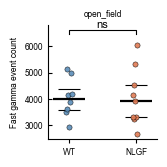

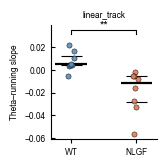

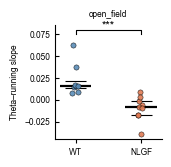

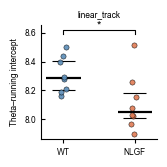

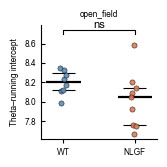

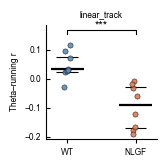

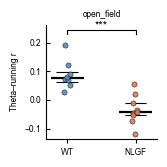

Done.
Saved results and figures to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis


In [81]:
"""
Analysis of PAC comodulogram metrics (modulation index, preferred phase) would follow a similar structure:
It will save:
lfp_stats_outputs/
  mannwhitney_results.csv
  <metric>_<task>_violin.pdf
  <metric>_<genotype>_paired_tasks.pdf).
"""

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf

# ─── Journal / Illustrator global styles ──────────────────────────────────────
mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.grid": False,
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "ytick.left": True,
    "ytick.direction": "in",
    "savefig.transparent": True,
    "savefig.bbox": "tight",
})

GENO_ORDER  = ["WT", "NLGF"]
GENO_COLORS = {"NLGF": "#E07B54", "WT": "#5B8DB8"}

def _pstars(p):
    if pd.isna(p): return ""
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "ns"



# ─── Metrics to analyse ───────────────────────────────────────────────────────
metrics = {
    "max_theta_freq": "Theta peak frequency (Hz)",
    "comodulogram_PAC_slow_gamma": "Theta–slow gamma PAC",
    "comodulogram_PAC_fast_gamma": "Theta–fast gamma PAC",
    "n_oscillatory_epochs_slow_gamm": "Slow gamma event count",
    "n_oscillatory_epochs_fast_gamma": "Fast gamma event count",
    "theta_running_slope": "Theta–running slope",
    "theta_running_intercept": "Theta–running intercept",
    "theta_running_rvalue": "Theta–running r",
}

metrics = {k: v for k, v in metrics.items() if k in df.columns}


# ─── Mann–Whitney tests: WT vs NLGF within each task ───────────────────────────
mw_results = []

for metric in metrics:
    for env in sorted(df["environment"].dropna().unique()):
        sub = df.loc[df["environment"] == env, ["Genotype", metric]].dropna()

        wt = sub.loc[sub["Genotype"] == "WT", metric].values
        ko = sub.loc[sub["Genotype"] == "NLGF", metric].values

        if len(wt) > 0 and len(ko) > 0:
            stat, p = mannwhitneyu(wt, ko, alternative="two-sided")
        else:
            stat, p = np.nan, np.nan

        mw_results.append({
            "metric": metric,
            "environment": env,
            "n_WT": len(wt),
            "n_NLGF": len(ko),
            "WT_median": np.nanmedian(wt) if len(wt) else np.nan,
            "NLGF_median": np.nanmedian(ko) if len(ko) else np.nan,
            "mannwhitney_U": stat,
            "pvalue": p,
            "stars": _pstars(p),
        })

mw_results = pd.DataFrame(mw_results)
mw_results.to_csv(os.path.join(OUTPUT_DIR, "mannwhitney_results.csv"), index=False)


# ─── Plotting helper ──────────────────────────────────────────────────────────
def plot_metric_violin(data, metric, ylabel, save=True):
    envs = sorted(data["environment"].dropna().unique())

    for env in envs:
        sub = data.loc[data["environment"] == env].copy()
        sub = sub[["Genotype", "mouse_name", metric]].dropna()

        genos = [g for g in GENO_ORDER if g in sub["Genotype"].astype(str).values]

        if len(genos) < 2:
            continue

        vals = {
            g: sub.loc[sub["Genotype"].astype(str) == g, metric].values
            for g in genos
        }

        fig, ax = plt.subplots(figsize=(1.65, 1.65))

        # ── Violin Mann–Whitney results ────────────────────────────────────────────────────
        # if all(len(vals[g]) >= 3 for g in genos):
        #     with warnings.catch_warnings():
        #         warnings.simplefilter("ignore")
        #         parts = ax.violinplot(
        #             [vals[g] for g in genos],
        #             positions=list(range(len(genos))),
        #             showmedians=False,
        #             showextrema=False,
        #             widths=0.8,
        #         )

        #     for i_v, pc in enumerate(parts["bodies"]):
        #         pc.set_facecolor(GENO_COLORS.get(genos[i_v], "#aaaaaa"))
        #         pc.set_alpha(0.45)
        #         pc.set_edgecolor("none")

        # ── Median and IQR ───────────────────────────────────────────────────
        for xi, g in enumerate(genos):
            if len(vals[g]) == 0:
                continue

            q1  = np.nanpercentile(vals[g], 25)
            med = np.nanmedian(vals[g])
            q3  = np.nanpercentile(vals[g], 75)

            ax.hlines([q1, q3], xi - 0.16, xi + 0.16,
                      colors="black", linewidth=0.8, zorder=7)
            ax.hlines(med, xi - 0.24, xi + 0.24,
                      colors="black", linewidth=1.6, zorder=8)

        # ── Individual points ────────────────────────────────────────────────
        rng = np.random.default_rng(10)

        for xi, g in enumerate(genos):
            y = vals[g]
            jitter = rng.normal(0, 0.045, size=len(y))
            ax.scatter(
                np.full(len(y), xi) + jitter,
                y,
                s=14,
                color=GENO_COLORS.get(g, "#aaaaaa"),
                edgecolor="black",
                linewidth=0.35,
                alpha=0.9,
                zorder=10,
            )

        # ── Mann–Whitney annotation ──────────────────────────────────────────
        p_row = mw_results[
            (mw_results["metric"] == metric) &
            (mw_results["environment"] == env)
        ]

        if len(p_row):
            p = p_row["pvalue"].iloc[0]
            stars = _pstars(p)

            ymax = np.nanmax(sub[metric].values)
            ymin = np.nanmin(sub[metric].values)
            yrng = ymax - ymin if ymax > ymin else ymax * 0.1

            y = ymax + 0.12 * yrng
            h = 0.04 * yrng

            ax.plot([0, 0, 1, 1], [y, y+h, y+h, y],
                    color="black", linewidth=0.8, clip_on=False)
            ax.text(0.5, y+h, stars, ha="center", va="bottom", fontsize=8)

        # ── Axes ─────────────────────────────────────────────────────────────
        ax.set_xticks(range(len(genos)))
        ax.set_xticklabels(genos)
        ax.set_ylabel(ylabel)
        ax.set_title(env)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        fig.tight_layout()

        if save:
            clean_metric = metric.replace("/", "_")
            clean_env = env.replace(" ", "_")
            fig.savefig(
                os.path.join(OUTPUT_DIR, f"{clean_metric}_{clean_env}_violin.pdf")
            )
        plt.show()
        plt.close(fig)

# ─── Make all violin plots ────────────────────────────────────────────────────
for metric, ylabel in metrics.items():
    plot_metric_violin(df, metric, ylabel)    


print("Done.")
print(f"Saved results and figures to: {OUTPUT_DIR}")

## Repeated measures ANOVA 

In [82]:
# ── Repeated-measures ANOVA (R via rpy2): gamma_band (within) × Genotype (between) ──
import pandas as pd
import numpy as np
from pathlib import Path
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

ro.r("suppressPackageStartupMessages(library(afex))")

# ── Load data ──────────────────────────────────────────────────────────────
basepath = Path('/Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis')
LFP_CSV_PATH = basepath / 'concatenated_lfp_stats.csv'
OUTPUT_DIR = LFP_CSV_PATH.parent / 'PAC_rm_anova_R_by_env'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(LFP_CSV_PATH)
df['mouse_name']  = df['mouse_name'].astype(str)
df['Genotype']    = df['Genotype'].astype(str)
df['environment'] = df['environment'].astype(str)

SLOW_COL = 'comodulogram_PAC_slow_gamma'
FAST_COL = 'comodulogram_PAC_fast_gamma'

def sig_label(p):
    if pd.isna(p): return 'NA'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def build_long_pac(sub_env):
    slow = sub_env[['mouse_name', 'Genotype', SLOW_COL]].rename(columns={SLOW_COL: 'PAC'})
    slow['gamma_band'] = 'slow'
    fast = sub_env[['mouse_name', 'Genotype', FAST_COL]].rename(columns={FAST_COL: 'PAC'})
    fast['gamma_band'] = 'fast'
    return pd.concat([slow, fast], ignore_index=True).dropna(subset=['PAC'])

def run_rm_anova_R(long_df):
    """Fit PAC ~ Genotype * gamma_band with mouse_name as within-subject error term, via afex::aov_ez."""
    with localconverter(ro.default_converter + pandas2ri.converter):
        r_df = ro.conversion.py2rpy(long_df)
    ro.globalenv['dat'] = r_df

    r_code = """
    suppressWarnings({
        dat$mouse_name <- factor(dat$mouse_name)
        dat$Genotype   <- factor(dat$Genotype, levels = c("WT", "NLGF"))
        dat$gamma_band <- factor(dat$gamma_band, levels = c("slow", "fast"))
        dat <- droplevels(dat)

        fit <- aov_ez(
            id      = "mouse_name",
            dv      = "PAC",
            data    = dat,
            between = "Genotype",
            within  = "gamma_band",
            type    = 3,
            anova_table = list(correction = "GG")   # Greenhouse-Geisser, moot here w/ 2 levels but safe default
        )

        aov_df <- as.data.frame(fit$anova_table)
        aov_df <- data.frame(term = rownames(aov_df), aov_df, row.names = NULL, check.names = FALSE)

        list(anova_table = aov_df)
    })
    """
    out = ro.r(r_code)
    with localconverter(ro.default_converter + pandas2ri.converter):
        aov_df = ro.conversion.rpy2py(out.rx2('anova_table'))
    return aov_df

# ── Run separately per environment ───────────────────────────────────────────
all_results = {}
rm_rows_summary = []

for env in sorted(df['environment'].dropna().unique()):
    print(f"\n{'='*70}\nENVIRONMENT: {env}\n{'='*70}")

    sub_env  = df[df['environment'] == env].copy()
    long_pac = build_long_pac(sub_env)

    # ── Check balance: every mouse must have exactly 2 rows (slow + fast) ────
    counts = long_pac.groupby('mouse_name').size()
    unbalanced = counts[counts != 2]
    if len(unbalanced) > 0:
        print(f"⚠️  Unbalanced design — these mice don't have both gamma bands, dropping them:")
        print(unbalanced)
        long_pac = long_pac[~long_pac['mouse_name'].isin(unbalanced.index)]

    n_mice = long_pac['mouse_name'].nunique()
    print(f"n rows = {len(long_pac)}, n mice (balanced) = {n_mice}, "
          f"genotypes = {sorted(long_pac['Genotype'].unique())}")

    if n_mice < 4:
        print("  Skipped: insufficient balanced data")
        continue

    try:
        aov_df = run_rm_anova_R(long_pac)
        print("\nRepeated-measures ANOVA (afex::aov_ez, Type III):")
        print(aov_df.to_string(index=False))

        all_results[env] = aov_df

        # afex column names: 'num Df', 'den Df', 'MSE', 'F', 'ges', 'Pr(>F)'
        p_col = [c for c in aov_df.columns if 'Pr' in c][0]
        for _, row in aov_df.iterrows():
            rm_rows_summary.append({
                'environment': env,
                'term':        row['term'],
                'F':           row.get('F', np.nan),
                'p_value':     row.get(p_col, np.nan),
                'sig':         sig_label(row.get(p_col, np.nan)),
            })

        aov_df.to_csv(OUTPUT_DIR / f"PAC_rm_anova_R_{env}.csv", index=False)
        print(f"Saved: {OUTPUT_DIR / f'PAC_rm_anova_R_{env}.csv'}")

    except Exception as e:
        print(f"  FAILED: {e}")

df_summary = pd.DataFrame(rm_rows_summary)
summary_path = OUTPUT_DIR / "PAC_rm_anova_R_summary_both_envs.csv"
df_summary.to_csv(summary_path, index=False)
print(f"\n✅ Combined summary saved to: {summary_path}")
print(df_summary.to_string(index=False))

R callback write-console: Contrasts set to contr.sum for the following variables: Genotype
  
R callback write-console: Contrasts set to contr.sum for the following variables: Genotype
  



ENVIRONMENT: linear_track
n rows = 34, n mice (balanced) = 17, genotypes = ['NLGF', 'WT']

Repeated-measures ANOVA (afex::aov_ez, Type III):
               term  num Df  den Df          MSE        F      ges   Pr(>F)
           Genotype     1.0    15.0 6.528809e-07 4.181604 0.133787 0.058825
         gamma_band     1.0    15.0 5.255256e-07 8.717927 0.205840 0.009881
Genotype:gamma_band     1.0    15.0 5.255256e-07 0.107365 0.003182 0.747693
Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis/PAC_rm_anova_R_by_env/PAC_rm_anova_R_linear_track.csv

ENVIRONMENT: open_field
n rows = 34, n mice (balanced) = 17, genotypes = ['NLGF', 'WT']

Repeated-measures ANOVA (afex::aov_ez, Type III):
               term  num Df  den Df      MSE        F      ges   Pr(>F)
           Genotype     1.0    15.0 0.000001 2.778062 0.085212 0.116302
         gamma_band     1.0    15.0 0.000001 8.261740 0.214926 0.011582
Geno

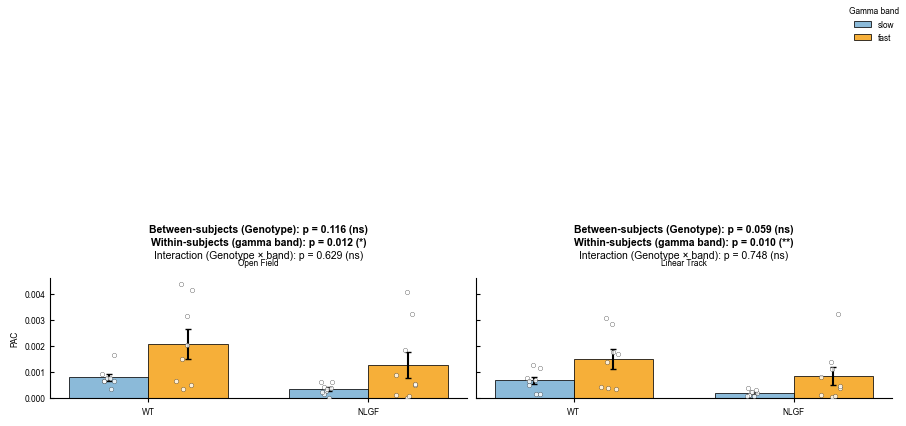

In [83]:
# Plot PAC separately by environment as grouped bar charts (slow/fast within genotype)
# Use ONLY repeated-measures ANOVA (df_summary) p-values for annotations.

plot_df = pac_kw_df.copy()

plot_df["Genotype"] = pd.Categorical(plot_df["Genotype"], categories=GENO_ORDER, ordered=True)
plot_df["gamma_band"] = pd.Categorical(plot_df["gamma_band"], categories=gamma_order, ordered=True)

envs = [
    e for e in env_order if e in plot_df["environment"].unique()
] if "env_order" in globals() else sorted(plot_df["environment"].dropna().unique())

gamma_palette = {"slow": "#7FB3D5", "fast": "#F5A623"}

def p_to_stars(p):
    if pd.isna(p):        return ""
    if p < 0.001:         return "***"
    if p < 0.01:          return "**"
    if p < 0.05:          return "*"
    return "ns"

def format_p(p):
    if pd.isna(p):    return "p = NA"
    if p < 0.001:     return "p < 0.001"
    return f"p = {p:.3f}"

# RM-ANOVA terms from df_summary (environment-specific)
geno_main_pvals  = {}
band_main_pvals  = {}
interaction_pvals = {}

if "df_summary" in globals() and isinstance(df_summary, pd.DataFrame):
    need_cols = {"environment", "term", "p_value"}
    if need_cols.issubset(df_summary.columns):
        tmp = df_summary.copy()
        tmp["term"] = tmp["term"].astype(str)

        tmp_geno = tmp[tmp["term"].str.fullmatch("Genotype", case=False)]
        geno_main_pvals = dict(zip(tmp_geno["environment"].astype(str), tmp_geno["p_value"]))

        tmp_band = tmp[tmp["term"].str.fullmatch("gamma_band", case=False)]
        band_main_pvals = dict(zip(tmp_band["environment"].astype(str), tmp_band["p_value"]))

        tmp_int = tmp[tmp["term"].str.contains(
            "Genotype:gamma_band|gamma_band:Genotype", case=False, regex=True)]
        interaction_pvals = dict(zip(tmp_int["environment"].astype(str), tmp_int["p_value"]))

# Taller figure to hold 3 annotation lines above each panel
fig, axes = plt.subplots(1, len(envs), figsize=(4.5 * len(envs), 4.2), sharey=True)
if len(envs) == 1:
    axes = [axes]

bar_width = 0.36
x = np.arange(len(GENO_ORDER))

for ax, env in zip(axes, envs):
    sub = plot_df[plot_df["environment"] == env].copy()

    summary = (
        sub.groupby(["Genotype", "gamma_band"], observed=False)["PAC"]
        .agg(mean="mean", sem="sem", n="count")
        .reset_index()
    )

    for i, gamma in enumerate(gamma_order):
        means, sems = [], []
        for geno in GENO_ORDER:
            row = summary[
                (summary["Genotype"].astype(str) == geno) &
                (summary["gamma_band"].astype(str) == gamma)
            ]
            if len(row):
                means.append(float(row["mean"].iloc[0]))
                sems.append(float(row["sem"].iloc[0]) if pd.notna(row["sem"].iloc[0]) else 0.0)
            else:
                means.append(np.nan)
                sems.append(0.0)

        xpos = x + (i - 0.5) * bar_width
        ax.bar(xpos, means, width=bar_width,
               color=gamma_palette.get(gamma, "#aaaaaa"),
               edgecolor="black", linewidth=0.6,
               yerr=sems, capsize=2, label=gamma, alpha=0.9, zorder=2)

    # Overlay individual data points
    rng = np.random.default_rng(10)
    for i, gamma in enumerate(gamma_order):
        for j, geno in enumerate(GENO_ORDER):
            vals = sub.loc[
                (sub["Genotype"].astype(str) == geno) &
                (sub["gamma_band"].astype(str) == gamma), "PAC"
            ].dropna().values
            if len(vals) == 0:
                continue
            center = x[j] + (i - 0.5) * bar_width
            jitter = rng.normal(0, 0.03, size=len(vals))
            ax.scatter(np.full(len(vals), center) + jitter, vals,
                       s=10, color="white", edgecolor="black",
                       linewidth=0.25, alpha=0.8, zorder=3)

    # ── RM-ANOVA annotations above title ─────────────────────────────────────
    # Stacked in transAxes coordinates, 0.11 apart — never overlap data:
    #   y=1.37  Between-subjects: Genotype
    #   y=1.26  Within-subjects:  gamma band
    #   y=1.15  Interaction
    #   y=1.04  panel title

    p_geno = geno_main_pvals.get(str(env), np.nan)
    p_band = band_main_pvals.get(str(env), np.nan)
    p_int  = interaction_pvals.get(str(env), np.nan)

    if pd.notna(p_geno):
        ax.text(0.5, 1.37,
                f"Between-subjects (Genotype): {format_p(p_geno)} ({p_to_stars(p_geno)})",
                transform=ax.transAxes, ha="center", va="bottom",
                fontsize=7.5, fontweight="bold", clip_on=False)

    if pd.notna(p_band):
        ax.text(0.5, 1.26,
                f"Within-subjects (gamma band): {format_p(p_band)} ({p_to_stars(p_band)})",
                transform=ax.transAxes, ha="center", va="bottom",
                fontsize=7.5, fontweight="bold", clip_on=False)

    if pd.notna(p_int):
        ax.text(0.5, 1.15,
                f"Interaction (Genotype \u00d7 band): {format_p(p_int)} ({p_to_stars(p_int)})",
                transform=ax.transAxes, ha="center", va="bottom",
                fontsize=7.5, clip_on=False)

    ax.set_title(env_labels.get(env, env) if "env_labels" in globals() else env, y=1.04)
    ax.set_xlabel("")
    ax.set_xticks(x)
    ax.set_xticklabels(GENO_ORDER)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("PAC")
for ax in axes[1:]:
    ax.set_ylabel("")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:2], labels[:2], title="Gamma band", frameon=False, loc="upper right")

# rect top=0.68 → 32 % of figure height reserved for the 3 annotation lines
fig.tight_layout(rect=[0, 0, 1, 0.68])
plt.show()

## MLM PAC ~ Genotype * gamma_band * environment

In [84]:
# ── Full 3-way mixed model: PAC ~ Genotype * gamma_band * environment ────────
# Corrected: forces contr.sum contrasts before fitting so Type III ANOVA is valid.
# Adds: within-environment genotype contrasts, interaction contrast
#       (genotype-effect-difference-across-environments), and within-genotype
#       environment contrasts.

import pandas as pd
import numpy as np
from pathlib import Path
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

ro.r("suppressPackageStartupMessages(library(lme4))")
ro.r("suppressPackageStartupMessages(library(lmerTest))")
ro.r("suppressPackageStartupMessages(library(emmeans))")

SLOW_COL = 'comodulogram_PAC_slow_gamma'
FAST_COL = 'comodulogram_PAC_fast_gamma'

def sig_label(p):
    if pd.isna(p): return 'NA'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

# ── Build long-format PAC (slow + fast, both environments) ───────────────────
slow = df[['mouse_name', 'Genotype', 'environment', SLOW_COL]].rename(columns={SLOW_COL: 'PAC'})
slow['gamma_band'] = 'slow'
fast = df[['mouse_name', 'Genotype', 'environment', FAST_COL]].rename(columns={FAST_COL: 'PAC'})
fast['gamma_band'] = 'fast'

long_pac = pd.concat([slow, fast], ignore_index=True).dropna(subset=['PAC'])
long_pac['mouse_name']  = long_pac['mouse_name'].astype(str)
long_pac['Genotype']    = long_pac['Genotype'].astype(str)
long_pac['environment'] = long_pac['environment'].astype(str)
long_pac['gamma_band']  = long_pac['gamma_band'].astype(str)

print(f"n rows = {len(long_pac)}, n mice = {long_pac['mouse_name'].nunique()}")
print(long_pac.groupby(['environment', 'Genotype', 'gamma_band'])['PAC'].agg(['count', 'median']))

# ── Pass to R and fit model ───────────────────────────────────────────────────
with localconverter(ro.default_converter + pandas2ri.converter):
    r_df = ro.conversion.py2rpy(long_pac)
ro.globalenv['dat'] = r_df

r_code = """
suppressWarnings({
    dat$mouse_name  <- factor(dat$mouse_name)
    dat$Genotype    <- factor(dat$Genotype,    levels = c("WT", "NLGF"))
    dat$gamma_band  <- factor(dat$gamma_band,  levels = c("slow", "fast"))
    dat$environment <- factor(dat$environment)

    # ── Force sum-to-zero contrasts for valid Type III tests ─────────────────
    # (plain lmer() defaults to treatment contrasts, which make Type III
    #  main-effect tests invalid whenever interactions are also in the model)
    contrasts(dat$Genotype)    <- contr.sum(nlevels(dat$Genotype))
    contrasts(dat$gamma_band)  <- contr.sum(nlevels(dat$gamma_band))
    contrasts(dat$environment) <- contr.sum(nlevels(dat$environment))

    # Full mixed model: fixed = Genotype * gamma_band * environment
    #                   random = (1 | mouse_name)
    fit <- lmer(PAC ~ Genotype * gamma_band * environment + (1 | mouse_name),
                data = dat, REML = FALSE)

    conv <- tryCatch(!is.null(fit@optinfo$conv$lme4$code) == FALSE, error = function(e) NA)

    # Type III Wald F-tests (lmerTest), now valid with contr.sum in place
    aov_table <- as.data.frame(anova(fit, type = 3))
    aov_table <- data.frame(term = rownames(aov_table), aov_table,
                            row.names = NULL, check.names = FALSE)

    # ── 1. Genotype contrast within each environment (simple effects) ────────
    emm_geno_by_env <- emmeans(fit, ~ Genotype | environment)
    geno_by_env_df  <- as.data.frame(contrast(emm_geno_by_env, method = "pairwise"))

    # ── 2. Interaction contrast: is the genotype effect itself different  ────
    #        between environments? (difference-of-differences)
    emm_full <- emmeans(fit, ~ Genotype * environment)
    interaction_contrast_df <- as.data.frame(
        contrast(emm_full, interaction = "pairwise")
    )

    # ── 3. Environment contrast within each genotype ──────────────────────────
    emm_env_by_geno <- emmeans(fit, ~ environment | Genotype)
    env_by_geno_df  <- as.data.frame(contrast(emm_env_by_geno, method = "pairwise"))

    # Random effect variance + model fit diagnostics
    re_var  <- as.numeric(VarCorr(fit)$mouse_name[1,1])
    aic_val <- AIC(fit)

    list(
        anova_table              = aov_table,
        genotype_within_env      = geno_by_env_df,
        interaction_contrast     = interaction_contrast_df,
        environment_within_geno  = env_by_geno_df,
        re_var                  = re_var,
        aic                     = aic_val
    )
})
"""
out = ro.r(r_code)

with localconverter(ro.default_converter + pandas2ri.converter):
    aov_df           = ro.conversion.rpy2py(out.rx2('anova_table'))
    geno_within_env  = ro.conversion.rpy2py(out.rx2('genotype_within_env'))
    interaction_df   = ro.conversion.rpy2py(out.rx2('interaction_contrast'))
    env_within_geno  = ro.conversion.rpy2py(out.rx2('environment_within_geno'))

re_var  = float(out.rx2('re_var')[0])
aic_val = float(out.rx2('aic')[0])

# ── Print results ─────────────────────────────────────────────────────────────
print(f"\nAIC: {aic_val:.2f}  |  RE variance (mouse): {re_var:.6f}")

print("\n─── Type III ANOVA (lmerTest, contr.sum) ─────────────────────────────")
print(aov_df.to_string(index=False))

print("\n─── 1. Genotype contrast within each environment (simple effects) ────")
print(geno_within_env.to_string(index=False))

print("\n─── 2. Interaction contrast: genotype effect, linear_track vs open_field ──")
print(interaction_df.to_string(index=False))

print("\n─── 3. Environment contrast within each genotype ──────────────────────")
print(env_within_geno.to_string(index=False))

# ── Save ──────────────────────────────────────────────────────────────────────
out_dir = Path(OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

aov_df.to_csv(out_dir / "PAC_lmer_anova_table_contrsum.csv", index=False)
geno_within_env.to_csv(out_dir / "PAC_lmer_genotype_within_env.csv", index=False)
interaction_df.to_csv(out_dir / "PAC_lmer_interaction_contrast.csv", index=False)
env_within_geno.to_csv(out_dir / "PAC_lmer_environment_within_genotype.csv", index=False)

print(f"\n✅ Saved to: {OUTPUT_DIR}")

n rows = 68, n mice = 17
                                  count    median
environment  Genotype gamma_band                 
linear_track NLGF     fast            9  0.000445
                      slow            9  0.000188
             WT       fast            8  0.001543
                      slow            8  0.000687
open_field   NLGF     fast            9  0.000555
                      slow            9  0.000363
             WT       fast            8  0.001761
                      slow            8  0.000703


R callback write-console: NOTE: Results may be misleading due to involvement in interactions
  
R callback write-console: NOTE: Results may be misleading due to involvement in interactions
  
R callback write-console: NOTE: Results may be misleading due to involvement in interactions
  



AIC: -746.78  |  RE variance (mouse): 0.000000

─── Type III ANOVA (lmerTest, contr.sum) ─────────────────────────────
                           term       Sum Sq      Mean Sq  NumDF  DenDF   F value   Pr(>F)
                       Genotype 2.457214e-06 2.457214e-06      1   17.0  4.176156 0.056812
                     gamma_band 1.430656e-05 1.430656e-05      1   51.0 24.314694 0.000009
                    environment 1.744557e-06 1.744557e-06      1   51.0  2.964959 0.091147
            Genotype:gamma_band 3.105970e-07 3.105970e-07      1   51.0  0.527875 0.470823
           Genotype:environment 2.405991e-08 2.405991e-08      1   51.0  0.040891 0.840553
         gamma_band:environment 5.705665e-07 5.705665e-07      1   51.0  0.969706 0.329402
Genotype:gamma_band:environment 4.901211e-08 4.901211e-08      1   51.0  0.083298 0.774046

─── 1. Genotype contrast within each environment (simple effects) ────
 contrast  environment  estimate       SE        df  t.ratio  p.value
WT - NLGF 

## MLM metric ~ Genotype * environment + (1 | mouse_name)


/Users/loukia/miniconda3/envs/scripts/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/loukia/miniconda3/envs/scripts/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/loukia/miniconda3/envs/scripts/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/loukia/miniconda3/envs/scripts/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/loukia/miniconda3/envs/scripts/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be

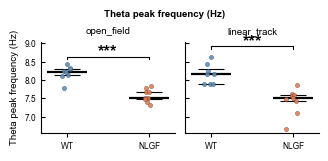

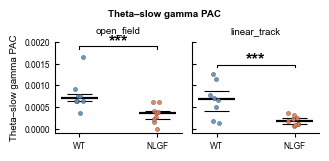

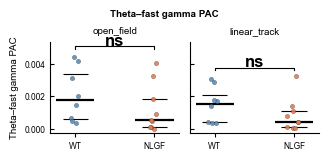

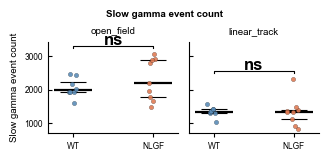

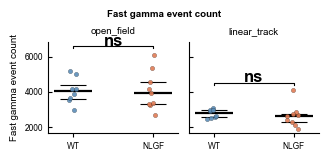

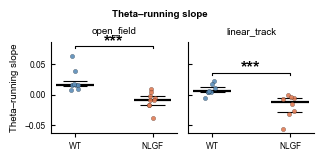

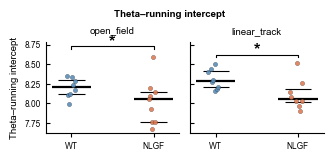

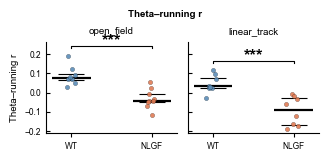

Done.
Saved results and figures to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis/LFP_analysis_mixed_model_outputs


In [85]:
"""
LFP analysis:
- Mixed linear models:
    metric ~ Genotype * environment + (1 | mouse_name)

- Violin plots:
    raw data shown as violins/points
    significance stars come from mixed-model genotype contrasts
    within each environment
"""

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.stats import norm
import statsmodels.formula.api as smf


# ─── Journal / Illustrator global styles ──────────────────────────────────────
mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.grid": False,
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "ytick.left": True,
    "ytick.direction": "in",
    "savefig.transparent": True,
    "savefig.bbox": "tight",
})

GENO_ORDER  = ["WT", "NLGF"]
GENO_COLORS = {"NLGF": "#E07B54", "WT": "#5B8DB8"}


def _pstars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


# ─── Load data ────────────────────────────────────────────────────────────────
basepath = Path(
    "/Users/loukia/Library/CloudStorage/Dropbox-UCL/"
    "Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/"
    "RobinData/Analysis/LFP_analysis"
)

LFP_CSV_PATH = basepath / "concatenated_lfp_stats.csv"
OUTPUT_DIR = LFP_CSV_PATH.parent / "LFP_analysis_mixed_model_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(LFP_CSV_PATH)

df["Genotype"] = pd.Categorical(
    df["Genotype"],
    categories=GENO_ORDER,
    ordered=True
)

df["environment"] = df["environment"].astype(str)
df["mouse_name"] = df["mouse_name"].astype(str)

if "Experimenter" in df.columns:
    df["Experimenter"] = df["Experimenter"].astype(str)


# ─── Metrics to analyse ───────────────────────────────────────────────────────
metrics = {
    "max_theta_freq": "Theta peak frequency (Hz)",
    "comodulogram_PAC_slow_gamma": "Theta–slow gamma PAC",
    "comodulogram_PAC_fast_gamma": "Theta–fast gamma PAC",
    "n_oscillatory_epochs_slow_gamm": "Slow gamma event count",
    "n_oscillatory_epochs_fast_gamma": "Fast gamma event count",
    "theta_running_slope": "Theta–running slope",
    "theta_running_intercept": "Theta–running intercept",
    "theta_running_rvalue": "Theta–running r",
}

metrics = {k: v for k, v in metrics.items() if k in df.columns}


# ─── Mixed models + LMM genotype contrasts for plotting ───────────────────────
mixed_results = []
lmm_plot_pvals = []

for metric in metrics:

    model_df = df[[
        metric,
        "Genotype",
        "environment",
        "mouse_name"
    ]].dropna()

    if model_df["Genotype"].nunique() < 2:
        continue

    if model_df["environment"].nunique() < 2:
        continue

    try:
        model = smf.mixedlm(
            f"{metric} ~ Genotype * environment",
            data=model_df,
            groups=model_df["mouse_name"]
        )

        fit = model.fit(reml=False, method="lbfgs")

        # Save full model terms
        for term, beta in fit.params.items():
            mixed_results.append({
                "metric": metric,
                "term": term,
                "beta": beta,
                "se": fit.bse.get(term, np.nan),
                "z": fit.tvalues.get(term, np.nan),
                "pvalue": fit.pvalues.get(term, np.nan),
                "stars": _pstars(fit.pvalues.get(term, np.nan)),
                "n": model_df.shape[0],
                "n_mice": model_df["mouse_name"].nunique(),
            })

        # Environment-specific NLGF vs WT contrasts from the LMM
        params = fit.params
        cov = fit.cov_params()

        for env in sorted(model_df["environment"].dropna().unique()):

            contrast = pd.Series(0.0, index=params.index)

            if "Genotype[T.NLGF]" in contrast.index:
                contrast["Genotype[T.NLGF]"] = 1.0

            interaction_term = f"Genotype[T.NLGF]:environment[T.{env}]"

            if interaction_term in contrast.index:
                contrast[interaction_term] = 1.0

            beta = float(np.dot(contrast, params))
            se = float(np.sqrt(np.dot(contrast, np.dot(cov, contrast))))

            if se > 0:
                z = beta / se
                p = 2 * (1 - norm.cdf(abs(z)))
            else:
                z = np.nan
                p = np.nan

            lmm_plot_pvals.append({
                "metric": metric,
                "environment": env,
                "contrast": "NLGF_vs_WT",
                "beta": beta,
                "se": se,
                "z": z,
                "pvalue": p,
                "stars": _pstars(p),
                "n": model_df.loc[
                    model_df["environment"] == env
                ].shape[0],
                "n_mice": model_df.loc[
                    model_df["environment"] == env,
                    "mouse_name"
                ].nunique(),
            })

        clean_metric = metric.replace("/", "_")

        with open(
            os.path.join(OUTPUT_DIR, f"mixed_model_{clean_metric}.txt"),
            "w"
        ) as f:
            f.write(str(fit.summary()))

    except Exception as e:
        mixed_results.append({
            "metric": metric,
            "term": "MODEL_FAILED",
            "beta": np.nan,
            "se": np.nan,
            "z": np.nan,
            "pvalue": np.nan,
            "stars": "",
            "n": model_df.shape[0],
            "n_mice": model_df["mouse_name"].nunique(),
            "error": str(e),
        })


mixed_results = pd.DataFrame(mixed_results)
mixed_results.to_csv(
    os.path.join(OUTPUT_DIR, "mixed_model_results.csv"),
    index=False
)

lmm_plot_pvals = pd.DataFrame(lmm_plot_pvals)
lmm_plot_pvals.to_csv(
    os.path.join(OUTPUT_DIR, "mixed_model_plot_pvalues.csv"),
    index=False
)

# ─── Plotting helper: raw data violins + MLM genotype contrasts ──────────────
def plot_metric_violin_mlm(data, metric, ylabel, save=True):
    env_order = ["open_field", "linear_track"]
    envs = [env for env in env_order if env in data["environment"].dropna().unique()]

    if len(envs) == 0:
        return
    fig, axes = plt.subplots(
        1,
        len(envs),
        figsize=(3.3, 1.65),
        sharey=True,
    )

    if len(envs) == 1:
        axes = [axes]

    rng = np.random.default_rng(10)

    for ax, env in zip(axes, envs):
        sub = data.loc[data["environment"] == env].copy()
        sub = sub[["Genotype", "mouse_name", metric]].dropna()

        genos = [
            g for g in GENO_ORDER
            if g in sub["Genotype"].astype(str).values
        ]

        if len(genos) < 2:
            ax.set_visible(False)
            continue

        vals = {
            g: sub.loc[sub["Genotype"].astype(str) == g, metric].values
            for g in genos
        }

        # if all(len(vals[g]) >= 3 for g in genos):
        #     with warnings.catch_warnings():
        #         warnings.simplefilter("ignore")
        #         parts = ax.violinplot(
        #             [vals[g] for g in genos],
        #             positions=list(range(len(genos))),
        #             showmedians=False,
        #             showextrema=False,
        #             widths=0.8,
        #         )

        #     for i_v, pc in enumerate(parts["bodies"]):
        #         pc.set_facecolor(GENO_COLORS.get(genos[i_v], "#aaaaaa"))
        #         pc.set_alpha(0.45)
        #         pc.set_edgecolor("none")

        for xi, g in enumerate(genos):
            if len(vals[g]) == 0:
                continue

            q1 = np.nanpercentile(vals[g], 25)
            med = np.nanmedian(vals[g])
            q3 = np.nanpercentile(vals[g], 75)

            ax.hlines(
                [q1, q3],
                xi - 0.16,
                xi + 0.16,
                colors="black",
                linewidth=0.8,
                zorder=7,
            )
            ax.hlines(
                med,
                xi - 0.24,
                xi + 0.24,
                colors="black",
                linewidth=1.6,
                zorder=8,
            )

            jitter = rng.normal(0, 0.048, size=len(vals[g]))
            ax.scatter(
                np.full(len(vals[g]), xi) + jitter,
                vals[g],
                s=10,
                color=GENO_COLORS.get(g, "#aaaaaa"),
                edgecolor="black",
                linewidth=0.15,
                alpha=0.9,
                zorder=10,
            )

        # MLM annotation from the mixed-model cell above
        p_row = lmm_plot_pvals[
            (lmm_plot_pvals["metric"] == metric) &
            (lmm_plot_pvals["environment"] == env) &
            (lmm_plot_pvals["contrast"] == "NLGF_vs_WT")
        ]

        if len(p_row):
            p = p_row["pvalue"].iloc[0]
            stars = _pstars(p)

            ymax = np.nanmax(sub[metric].values)
            ymin = np.nanmin(sub[metric].values)
            yrng = ymax - ymin if ymax > ymin else max(abs(ymax) * 0.1, 1.0)

            y = ymax + 0.12 * yrng
            h = 0.04 * yrng

            ax.plot(
                [0, 0, 1, 1],
                [y, y + h, y + h, y],
                color="black",
                linewidth=0.8,
                clip_on=False,
            )
            ax.text(
                0.5,
                y,
                stars,
                ha="center",
                va="bottom",
                fontsize=12,
                fontweight="bold",
            )

        ax.set_xticks(range(len(genos)))
        ax.set_xticklabels(genos)
        ax.set_title(env)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel(ylabel)
    fig.suptitle(ylabel, y=0.92, fontsize=7, fontweight="bold")
    fig.tight_layout()

    if save:
        clean_metric = metric.replace("/", "_")
        fig.savefig(os.path.join(OUTPUT_DIR, f"{clean_metric}_violin_LMM.pdf"))

    plt.show()
    plt.close(fig)


# ─── Make all violin plots ────────────────────────────────────────────────────
for metric, ylabel in metrics.items():
    plot_metric_violin_mlm(df, metric, ylabel)

print("Done.")
print(f"Saved results and figures to: {OUTPUT_DIR}")

## Compare MLM vs Mann-Whitney U: concordance of significance 



Several reasons why the MLM is better suited to your data:

**1. Handles repeated measures properly**
Each mouse contributes data from both `open_field` and `linear_track`. Mann-Whitney treats all observations as independent — it doesn't know that two rows belong to the same mouse. The `(1|mouse_name)` random intercept explicitly models the correlation between repeated measurements from the same animal, giving you correct standard errors.

**2. Tests environment and genotype simultaneously**
Mann-Whitney only compares WT vs NLGF within one environment at a time. The MLM fits both environments in one model, so the `Genotype * environment` interaction term tells you directly whether **the genotype difference changes between environments** — something Mann-Whitney cannot answer at all.

**3. Borrows strength across environments**
By pooling all data into one model, the MLM uses more data when estimating genotype effects, giving better-powered estimates, especially when per-environment sample sizes are small.

**4. Accounts for mouse-level variability**
If some mice just have systematically higher/lower PAC regardless of genotype (which is very likely in neural data), the random intercept absorbs that variability. Mann-Whitney lumps it into the error, inflating noise.

**5. Effect size estimate**
The MLM gives you a `beta` (the estimated magnitude of the genotype difference in original units), not just a p-value. This is more informative for biological interpretation.

---

**When Mann-Whitney is still useful here:**
- Your data are non-normal (Shapiro-Wilk showed this) — Mann-Whitney makes no distributional assumptions, whereas the MLM assumes normally distributed residuals. With small n, this matters.
- It's simpler to explain and widely accepted in neuroscience.
- The concordance cell below compares both — if they agree, you have convergent evidence.

**Bottom line:** For your design (same mice, two environments, two genotypes), the MLM is statistically more appropriate. Mann-Whitney is a useful sanity check, but it ignores the repeated-measures structure.

In [87]:
# ── Compare MLM vs Mann-Whitney U: concordance of significance ───────────────
from IPython.display import display, HTML

ALPHA = 0.05

# Mixed linear model: environment-specific NLGF vs WT contrasts
mlm = lmm_plot_pvals[
    lmm_plot_pvals["contrast"] == "NLGF_vs_WT"
][[
    "metric",
    "environment",
    "beta",
    "se",
    "z",
    "pvalue",
    "n",
    "n_mice",
]].copy()

mlm = mlm.rename(columns={
    "beta": "mlm_beta",
    "se": "mlm_se",
    "z": "mlm_z",
    "pvalue": "mlm_p",
    "n": "mlm_n",
    "n_mice": "mlm_n_mice",
})
mlm["mlm_sig"] = mlm["mlm_p"] < ALPHA

# Mann-Whitney
mwu = mw_results[[
    "metric",
    "environment",
    "n_WT",
    "n_NLGF",
    "WT_median",
    "NLGF_median",
    "mannwhitney_U",
    "pvalue",
]].copy()

mwu = mwu.rename(columns={
    "pvalue": "mwu_p",
})
mwu["mwu_sig"] = mwu["mwu_p"] < ALPHA

# Merge on metric × environment
comp = pd.merge(
    mlm,
    mwu,
    on=["metric", "environment"],
    how="outer",
    indicator=True,
)

# Classification
def classify(row):
    g = bool(row.get("mlm_sig")) if pd.notna(row.get("mlm_sig")) else False
    m = bool(row.get("mwu_sig")) if pd.notna(row.get("mwu_sig")) else False

    if g and m:
        return "both"
    if g:
        return "MLM only"
    if m:
        return "MWU only"
    return "neither"

comp["concordance"] = comp.apply(classify, axis=1)

# p-value formatter
def _fmt_p(p):
    if pd.isna(p):
        return "—"
    if p < 0.001:
        return f"{p:.4f} ***"
    if p < 0.01:
        return f"{p:.4f} **"
    if p < 0.05:
        return f"{p:.4f} *"
    return f"{p:.4f}"

# Force environment display order
env_order = ["open_field", "linear_track"]
comp["environment"] = pd.Categorical(
    comp["environment"],
    categories=env_order,
    ordered=True
)

# ── Display: summary by concordance ───────────────────────────────────────────
display(HTML("<h3>Mixed Linear Model vs Mann-Whitney U — concordance of significance</h3>"))

for label in ["both", "MLM only", "MWU only", "neither"]:
    grp = comp[comp["concordance"] == label].copy()
    if grp.empty:
        continue

    display(HTML(f"<h4>{label} ({len(grp)} comparisons)</h4>"))

    show = grp[[
        "metric",
        "environment",
        "mlm_p",
        "mlm_beta",
        "mlm_se",
        "mlm_z",
        "mwu_p",
        "mannwhitney_U",
        "WT_median",
        "NLGF_median",
        "n_WT",
        "n_NLGF",
    ]].sort_values(["environment", "metric"])

    def _colour_row(row):
        g = row.get("mlm_p", np.nan)
        m = row.get("mwu_p", np.nan)

        g_sig = pd.notna(g) and g < ALPHA
        m_sig = pd.notna(m) and m < ALPHA

        if g_sig and m_sig:
            bg = "#c8e6c9"
        elif g_sig or m_sig:
            bg = "#fff9c4"
        else:
            bg = ""

        return [f"background-color:{bg}" if bg else "" for _ in row]

    display(
        show.style
            .apply(_colour_row, axis=1)
            .format({
                "mlm_p": "{:.4f}",
                "mlm_beta": "{:.4f}",
                "mlm_se": "{:.4f}",
                "mlm_z": "{:.3f}",
                "mwu_p": "{:.4f}",
                "mannwhitney_U": "{:.2f}",
                "WT_median": "{:.4f}",
                "NLGF_median": "{:.4f}",
            })
            .set_properties(**{"font-size": "11px"})
    )

# ── Quick count summary ───────────────────────────────────────────────────────
print("\nConcordance counts")
print(comp["concordance"].value_counts().to_string())

# Optional compact summary by environment
print("\nConcordance by environment")
print(pd.crosstab(comp["environment"], comp["concordance"]).to_string())

# ── Save ──────────────────────────────────────────────────────────────────────
comp_path = os.path.join(OUTPUT_DIR, "mlm_vs_mwu_concordance.csv")
comp[[
    "metric",
    "environment",
    "mlm_p",
    "mlm_beta",
    "mlm_se",
    "mlm_z",
    "mlm_n",
    "mlm_n_mice",
    "mwu_p",
    "mannwhitney_U",
    "n_WT",
    "n_NLGF",
    "WT_median",
    "NLGF_median",
    "concordance",
]].to_csv(comp_path, index=False)

print(f"\nSaved: {comp_path}")

,metric,environment,mlm_p,mlm_beta,mlm_se,mlm_z,mwu_p,mannwhitney_U,WT_median,NLGF_median,n_WT,n_NLGF
3,comodulogram_PAC_slow_gamma,open_field,0.0007,-0.0005,0.0001,-3.382,0.0016,67.00,0.0007,0.0004,8,9
5,max_theta_freq,open_field,0.0000,-0.6153,0.1162,-5.295,0.0002,71.00,8.2328,7.5164,8,9
13,theta_running_rvalue,open_field,0.0000,-0.1213,0.0258,-4.695,0.0003,70.00,0.0763,-0.0424,8,9
15,theta_running_slope,open_field,0.0000,-0.0324,0.0071,-4.567,0.0002,71.00,0.0160,-0.0088,8,9
2,comodulogram_PAC_slow_gamma,linear_track,0.0003,-0.0005,0.0001,-3.622,0.0111,62.00,0.0007,0.0002,8,9
4,max_theta_freq,linear_track,0.0000,-0.7420,0.1162,-6.384,0.0001,72.00,8.1716,7.5102,8,9
10,theta_running_intercept,linear_track,0.0356,-0.1889,0.0899,-2.102,0.0281,53.00,8.2854,8.0512,8,8
12,theta_running_rvalue,linear_track,0.0000,-0.1444,0.0265,-5.449,0.0006,62.00,0.0322,-0.0897,8,8
14,theta_running_slope,linear_track,0.0002,-0.0271,0.0072,-3.736,0.0011,61.00,0.0052,-0.0114,8,8


,metric,environment,mlm_p,mlm_beta,mlm_se,mlm_z,mwu_p,mannwhitney_U,WT_median,NLGF_median,n_WT,n_NLGF
11,theta_running_intercept,open_field,0.0479,-0.1757,0.0888,-1.978,0.0745,55.00,8.2023,8.0526,8,9


,metric,environment,mlm_p,mlm_beta,mlm_se,mlm_z,mwu_p,mannwhitney_U,WT_median,NLGF_median,n_WT,n_NLGF
1,comodulogram_PAC_fast_gamma,open_field,0.1689,-0.0008,0.0006,-1.376,0.2359,49.00,0.0018,0.0006,8,9
7,n_oscillatory_epochs_fast_gamma,open_field,0.9765,10.1667,345.4417,0.029,0.8884,38.00,4016.5000,3918.0000,8,9
9,n_oscillatory_epochs_slow_gamm,open_field,0.2105,236.1806,188.6008,1.252,0.4807,28.00,1987.0000,2183.0000,8,9
0,comodulogram_PAC_fast_gamma,linear_track,0.2831,-0.0006,0.0006,-1.073,0.2359,49.00,0.0015,0.0004,8,9
6,n_oscillatory_epochs_fast_gamma,linear_track,0.6927,-136.5000,345.4417,-0.395,0.2359,49.00,2761.0000,2627.0000,8,9
8,n_oscillatory_epochs_slow_gamm,linear_track,0.9926,1.7500,188.6008,0.009,0.8884,38.00,1342.0000,1345.0000,8,9



Concordance counts
concordance
both        9
neither     6
MLM only    1

Concordance by environment
concordance   MLM only  both  neither
environment                          
open_field           1     4        3
linear_track         0     5        3

Saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/LFP_analysis/LFP_analysis_mixed_model_outputs/mlm_vs_mwu_concordance.csv
